In [ ]:
import os
from models.resnet import ResNetPatchClassifier
from models.mil_classifier import MILAttentionClassifier
from main import extract_patches, extract_features_per_wsi
import torch
from torch.utils.data import DataLoader
import pandas as pd
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from datasets.mildataset import WSIMILTestDataset

class bcolors:
    HEADER = "\033[95m"
    OKBLUE = "\033[94m"
    DEBUG = "\033[96m"
    INFO = "\033[95m"  # pink
    WARNING = "\033[93m"  # yellow
    ERROR = "\033[91m"
    ENDC = "\033[0m"
    BOLD = "\033[1m"
    UNDERLINE = "\033[4m"
    

def test_mil_classifier(model, feature_dir, device):
    model.eval()
    model.to(device)

    test_dataset = WSIMILTestDataset(feature_dir)
    # Using batch_size=1 for WSI because each "bag" is one WSI
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

    all_predictions = []
    all_true_labels = []
    wsi_names = []

    print(f"{bcolors.INFO}[INFO]{bcolors.ENDC} Starting model testing...")

    with torch.no_grad():
        for features, labels, wsi_name in test_loader:
            # Features are a list of tensors, each tensor is a bag of patches for one WSI
            # In our DataLoader, batch_size=1, so features will be a list containing one tensor
            features = features.squeeze(0).to(device) # Remove batch dimension, move to device
            labels = labels.to(device)

            output = model(features) # Output is logits for each class
            probabilities = torch.softmax(output, dim=1)[:, 1].cpu().item() # Probability of positive class (tumor)
            predicted_label = (probabilities > 0.5).long() # Binary prediction based on 0.5 threshold

            all_predictions.append(probabilities)
            all_true_labels.append(labels.cpu().item())
            wsi_names.append(wsi_name[0]) # wsi_name is a tuple

            print(f"WSI: {wsi_name[0]}, True Label: {labels.cpu().item()}, Predicted Probability (Tumor): {probabilities:.4f}, Predicted Class: {predicted_label.item()}")

    auc_score = roc_auc_score(all_true_labels, all_predictions)
    # Convert probabilities to binary predictions for other metrics
    binary_predictions = [1 if p > 0.5 else 0 for p in all_predictions]
    accuracy = accuracy_score(all_true_labels, binary_predictions)
    precision = precision_score(all_true_labels, binary_predictions, zero_division=0)
    recall = recall_score(all_true_labels, binary_predictions, zero_division=0)
    f1 = f1_score(all_true_labels, binary_predictions, zero_division=0)

    print(f"\n{bcolors.OKGREEN}--- Test Results ---{bcolors.ENDC}")
    print(f"Test AUC: {auc_score:.4f}")
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test Precision: {precision:.4f}")
    print(f"Test Recall: {recall:.4f}")
    print(f"Test F1-Score: {f1:.4f}")

    results_df = pd.DataFrame({
        'WSI_Name': wsi_names,
        'True_Label': all_true_labels,
        'Predicted_Probability': all_predictions,
        'Predicted_Class': binary_predictions
    })
    results_df.to_csv("mil_test_results.csv", index=False)
    print(f"{bcolors.INFO}[INFO]{bcolors.ENDC} Detailed results saved to mil_test_results.csv")

    return {
        'auc': auc_score,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }


# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"{bcolors.INFO}[INFO]{bcolors.ENDC} Using device: {device}")
# Test Patches
print(f"{bcolors.INFO}[INFO]{bcolors.ENDC} Starting test patch extraction...")
extract_patches(level=3, test=True) 
print(f"{bcolors.OKGREEN}Test patch extraction complete.{bcolors.ENDC}")
# Feature Extraction
patch_feature_extractor = ResNetPatchClassifier().to(device) 
test_patch_root_dir = os.path.join(os.getcwd(), "data", "camelyon16", "patches", "test", "level_3")
test_feature_save_dir = os.path.join(os.getcwd(), "data", "camelyon16", "features", "test", "level_3")
extract_features_per_wsi(test=True, level=3, model_name="resnet18_patch_classifier_final_20250710055900")
print(f"{bcolors.OKGREEN}Test feature extraction complete.{bcolors.ENDC}")
# Load the MIL model
model_path = "models/mil_classifier_attention_best_level3_resnet18_patch_classifier_final_level3_20250710055900.pth.pth"
mil_model = MILAttentionClassifier(feature_dim=512, num_classes=2) # Feature dim for ResNet18
mil_model.load_state_dict(torch.load(model_path, map_location=device))
print(f"{bcolors.INFO}[INFO]{bcolors.ENDC} Loaded MIL model from {model_path}")
# Run test evaluation
results = test_mil_classifier(mil_model, test_feature_save_dir, device)
print(f"Final Test AUC: {results['auc']:.4f}")



In [2]:
import re
import csv

def write_training_log_to_csv(log_text, csv_filename):
    """
    Parses the training log and writes epoch, train loss, train AUC, val loss, val AUC to a CSV file.
    """
    pattern = re.compile(
        r"\[Epoch\s+(\d+)\]\s+Train Loss:\s+([0-9.]+),\s+Train AUC:\s+([0-9.]+),\s+Val Loss:\s+([0-9.]+),\s+Val AUC:\s+([0-9.]+)"
    )
    rows = []
    for match in pattern.finditer(log_text):
        epoch = int(match.group(1))
        train_loss = float(match.group(2))
        train_auc = float(match.group(3))
        val_loss = float(match.group(4))
        val_auc = float(match.group(5))
        rows.append([epoch, train_loss, train_auc, val_loss, val_auc])

    with open(csv_filename, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['epoch', 'train loss', 'train AUC', 'val loss', 'val AUC'])
        writer.writerows(rows)


# write_training_log_to_csv(log_text, "training_log.csv")

In [ ]:
# Write the provided log string to CSV
log_text = '''[Epoch 001] Train Loss: 0.5833, Train AUC: 0.4977, Val Loss: 0.5865, Val AUC: 0.8210
[Epoch 002] Train Loss: 0.4525, Train AUC: 0.8710, Val Loss: 0.4274, Val AUC: 0.9259
[Epoch 003] Train Loss: 0.3220, Train AUC: 0.9381, Val Loss: 0.2830, Val AUC: 0.9383
[Epoch 004] Train Loss: 0.2559, Train AUC: 0.9529, Val Loss: 0.3479, Val AUC: 0.9506
[Epoch 005] Train Loss: 0.2343, Train AUC: 0.9564, Val Loss: 0.2543, Val AUC: 0.9506
[Epoch 006] Train Loss: 0.2291, Train AUC: 0.9564, Val Loss: 0.2416, Val AUC: 0.9506
[Epoch 007] Train Loss: 0.2214, Train AUC: 0.9597, Val Loss: 0.2723, Val AUC: 0.9506
[Epoch 008] Train Loss: 0.1968, Train AUC: 0.9681, Val Loss: 0.2543, Val AUC: 0.9506
[Epoch 009] Train Loss: 0.2155, Train AUC: 0.9639, Val Loss: 0.2713, Val AUC: 0.9506
[Epoch 010] Train Loss: 0.1913, Train AUC: 0.9705, Val Loss: 0.2421, Val AUC: 0.9506
[Epoch 011] Train Loss: 0.1713, Train AUC: 0.9747, Val Loss: 0.2450, Val AUC: 0.9506
[Epoch 012] Train Loss: 0.1660, Train AUC: 0.9765, Val Loss: 0.2478, Val AUC: 0.9506
[Epoch 013] Train Loss: 0.1630, Train AUC: 0.9775, Val Loss: 0.2503, Val AUC: 0.9506
[Epoch 014] Train Loss: 0.1627, Train AUC: 0.9775, Val Loss: 0.2544, Val AUC: 0.9506'''

write_training_log_to_csv(log_text, "training_log.csv")
print('CSV file "training_log.csv" has been written.')

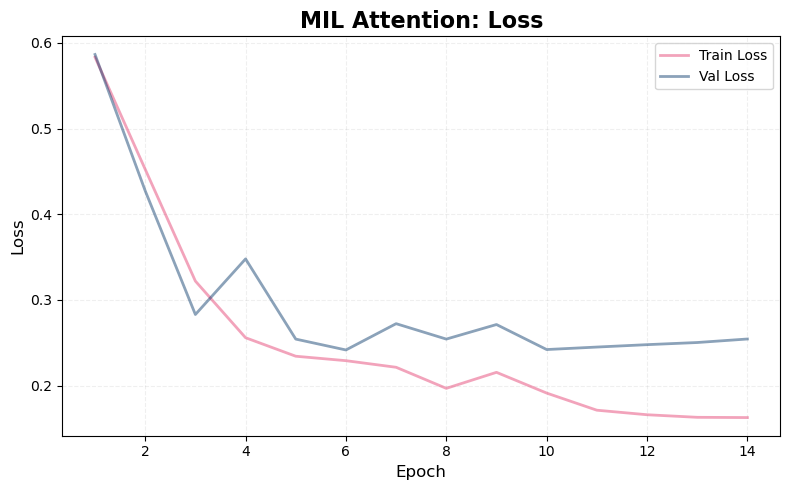

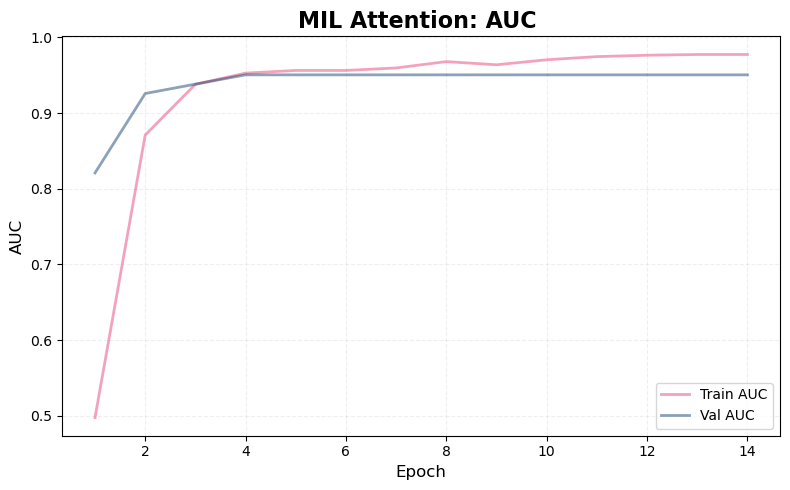

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the CSV file generated earlier
df = pd.read_csv("training_log.csv")

# Plot 1: Training and Validation Loss
plt.figure(figsize=(8,5))
plt.plot(df['epoch'], df['train loss'], color='#e7548088', label='Train Loss', linewidth=2)  # pink
plt.plot(df['epoch'], df['val loss'], color='#00336674', label='Val Loss', linewidth=2)  # dark blue
plt.title('MIL Attention: Cross Entropy Loss', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.2)
plt.tight_layout()
plt.show()

# Plot 2: Training and Validation AUC
plt.figure(figsize=(8,5))
plt.plot(df['epoch'], df['train AUC'], color="#e7548088", label='Train AUC', linewidth=2)  # pink
plt.plot(df['epoch'], df['val AUC'], color="#00336674", label='Val AUC', linewidth=2)  # dark blue
plt.title('MIL Attention: AUC ', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('AUC', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.2)
plt.tight_layout()
plt.show()